# Coordination and population density by commune — 2002 & 2022

At département level, CENP shows little or no association with population density in 2002 but a positive one in
2022. **Does the same pattern appear at commune level?**

Reads `data/processed/coordination_density_communes_corrected.csv` (built by `scripts/01`–`04`). 2002 and 2022 are
analysed as **two separate cross-sections** (no commune-level ΔCENP). Everything is descriptive.

**Main samples** (`main_sample`): metropolitan communes matched to INSEE, with finite log density and CENP, excluding
2002 communes flagged as possible boundary changes (registered / population outside [0.4, 1.2]). 2002 density uses
`population_2002_interp` (1999–2006 geometric interpolation), 2022 density uses the 2022 population.
Unweighted results are the main specification; WLS (weights = expressed votes) is a robustness check.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from svgeo.analysis import association_stats, commune_scatter, pooled_interaction, show_plot
from svgeo.config import COMMUNE_DENSITY, YEARS
from svgeo.utils import read_csv

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

merged = read_csv(COMMUNE_DENSITY)
main = merged[merged["main_sample"]].copy()
merged.groupby("year").agg(all=("commune_code", "size"), main_sample=("main_sample", "sum"))

,all,main_sample
year,,
2002,36674,33581
2022,35034,34112


## 1. CENP and density in each year

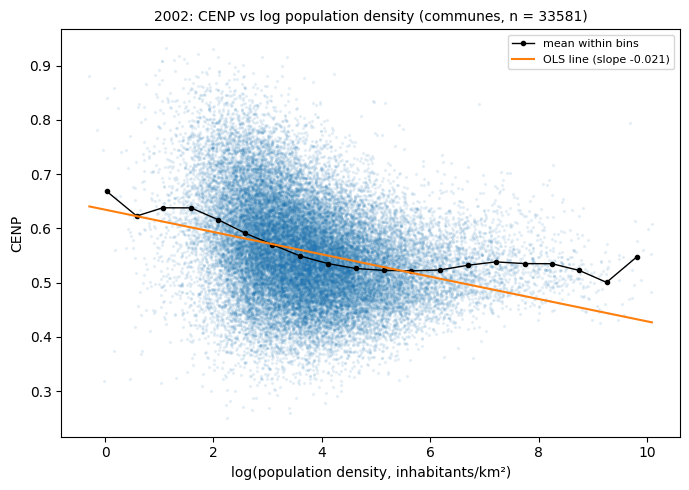

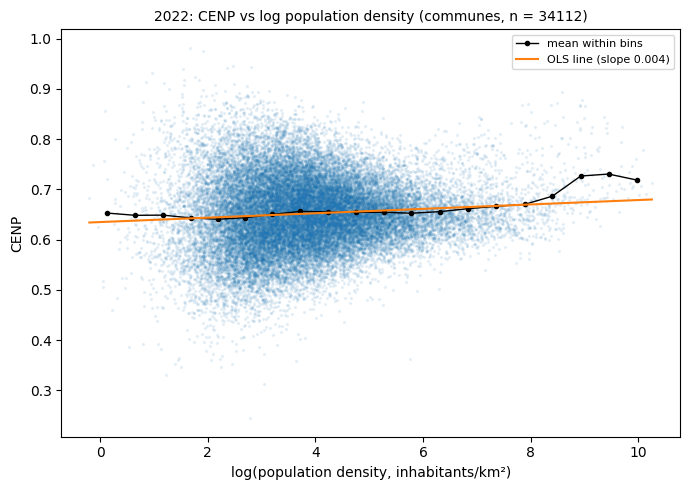

In [2]:
for year in YEARS:
    sub = main[main["year"] == year]
    fig, ax = plt.subplots(figsize=(7, 5))
    commune_scatter(sub, "CENP", ax, f"{year}: CENP vs log population density (communes, n = {len(sub)})", "CENP")
    show_plot(fig)

In [3]:
pd.DataFrame({year: association_stats(main[main["year"] == year], "CENP", weighted=True) for year in YEARS})

,2002,2022
n,33581.000000,3.411200e+04
pearson_r,-0.287421,8.180033e-02
pearson_p,0.000000,9.831408e-52
spearman_rho,-0.310497,7.698489e-02
spearman_p,0.000000,5.225800e-46
ols_coef,-0.020573,4.379877e-03
ols_se,0.000374,2.889403e-04
ols_se_HC1,0.000381,2.932182e-04
ols_p,0.000000,9.831408e-52
ols_p_HC1,0.000000,2.720541e-50


In [4]:
for year in YEARS:
    print(f"===== {year} =====")
    print(smf.ols("CENP ~ log_density", data=main[main["year"] == year]).fit().summary())

===== 2002 =====
                            OLS Regression Results                            
Dep. Variable:                   CENP   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     3024.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:09:26   Log-Likelihood:                 34247.
No. Observations:               33581   AIC:                        -6.849e+04
Df Residuals:                   33579   BIC:                        -6.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.6345      0.001

In [5]:
# 2002 robustness: including communes flagged as possible boundary changes / density from the 1999 census count
all_matched_2002 = merged[(merged["year"] == 2002) & merged["metropolitan"] & merged["insee_match"]
                          & np.isfinite(merged["log_density"]) & merged["CENP"].notna()].copy()
census99 = all_matched_2002.assign(density=all_matched_2002["population"] / all_matched_2002["surface_km2"])
with np.errstate(divide="ignore"):
    census99["log_density"] = np.log(census99["density"])
pd.DataFrame({
    "main sample": association_stats(main[main["year"] == 2002], "CENP"),
    "incl. flagged boundary changes": association_stats(all_matched_2002, "CENP"),
    "incl. flagged, 1999 census population": association_stats(census99[np.isfinite(census99["log_density"])], "CENP"),
})

,main sample,incl. flagged boundary changes,"incl. flagged, 1999 census population"
n,33581.000000,34717.000000,34717.000000
pearson_r,-0.287421,-0.309756,-0.305727
pearson_p,0.000000,0.000000,0.000000
spearman_rho,-0.310497,-0.328400,-0.324935
spearman_p,0.000000,0.000000,0.000000
ols_coef,-0.020573,-0.022078,-0.021790
ols_se,0.000374,0.000364,0.000364
ols_se_HC1,0.000381,0.000378,0.000377
ols_p,0.000000,0.000000,0.000000
ols_p_HC1,0.000000,0.000000,0.000000


## 2. Density deciles (within each year)

In [6]:
main["density_decile"] = main.groupby("year")["density"].transform(lambda s: pd.qcut(s, 10, labels=False) + 1)
by_decile = main.groupby(["year", "density_decile"]).agg(
    n_communes=("commune_code", "size"), density_median=("density", "median"),
    CENP_mean=("CENP", "mean"), CENP_median=("CENP", "median"),
    cliff_magnitude_mean=("cliff_magnitude", "mean"), cliff_ratio_mean=("cliff_ratio", "mean"),
)
by_decile

n_communes  density_median  CENP_mean  CENP_median  cliff_magnitude_mean  cliff_ratio_mean
year density_decile                                                                                            
2002 1                     3359        7.745410   0.620030     0.618242              0.122623          0.892995
     2                     3358       13.158763   0.592064     0.588170              0.108931          0.888559
     3                     3358       18.043161   0.578289     0.576713              0.102995          0.886310
     4                     3358       24.256334   0.565522     0.562598              0.099200          0.885553
     5                     3358       32.312145   0.556424     0.553385              0.095764          0.885001
     6                     3358       43.116982   0.541811     0.540314              0.090462          0.881550
     7                     3358       58.956222   0.535960     0.532116              0.089218          0.882133
     8                     3358       86.035781   0.528123     0.525961              0.085474          0.881414
     9                     3358      147.611220   0.523340     0.520825              0.084224          0.881505
     10                    3358      476.871573   0.526477     0.522123              0.081298          0.881823
2022 1                     3412        7.323615   0.641915     0.640174              0.153729          0.873161
     2                     3411       13.219616   0.643207     0.639863              0.152339          0.876911
     3                     3411       19.088319   0.643709     0.640841              0.150423          0.877730
     4                     3411       26.271186   0.653456     0.650201              0.154685          0.880330
     5                     3411       35.794183   0.654998     0.655054              0.154293          0.881173
     6                     3411       48.412698   0.656060     0.654296              0.152422          0.881761
     7                     3411       67.307692   0.654064     0.653723              0.147838          0.879696
     8                     3411       98.936170   0.655712     0.654286              0.149123          0.880691
     9                     3411      169.163763   0.654196     0.651968              0.146162          0.878991
     10                    3412      529.358078   0.660188     0.653649              0.154526          0.886491

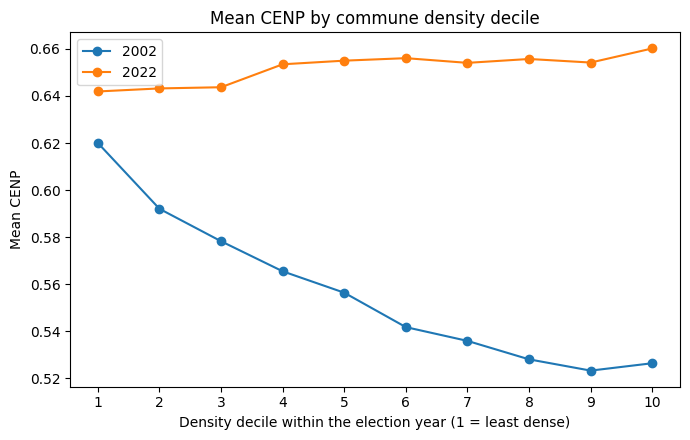

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for year in YEARS:
    ax.plot(by_decile.loc[year].index, by_decile.loc[year]["CENP_mean"], "o-", label=str(year))
ax.set_xticks(range(1, 11))
ax.set_xlabel("Density decile within the election year (1 = least dense)")
ax.set_ylabel("Mean CENP")
ax.set_title("Mean CENP by commune density decile")
ax.legend()
show_plot(fig)

## 3. Small-commune robustness

Coordination measures of communes with few voters are noisy. Same statistics for several minimum numbers of expressed
votes — none of these cutoffs is "the right one"; the point is to see whether tiny communes drive the association.

In [8]:
CUTOFFS = [0, 100, 500, 1000]
rows = []
for year in YEARS:
    for cutoff in CUTOFFS:
        sub = main[(main["year"] == year) & (main["expressed"] >= cutoff)]
        rows.append({"year": year, "min_expressed": cutoff, **association_stats(sub, "CENP", weighted=True)})
robustness = pd.DataFrame(rows).set_index(["year", "min_expressed"])
robustness[["n", "pearson_r", "spearman_rho", "ols_coef", "ols_se", "ols_se_HC1", "ols_p", "ols_R2",
            "wls_coef", "wls_se_HC1", "wls_p_HC1"]]

n  pearson_r  spearman_rho  ols_coef    ols_se  ols_se_HC1          ols_p    ols_R2  wls_coef  wls_se_HC1     wls_p_HC1
year min_expressed                                                                                                                             
2002 0              33581  -0.287421     -0.310497 -0.020573  0.000374    0.000381   0.000000e+00  0.082611 -0.001673    0.001192  1.603657e-01
     100            27033  -0.165327     -0.185130 -0.010812  0.000392    0.000383  6.256148e-165  0.027333 -0.000539    0.001155  6.404903e-01
     500             9350  -0.011884     -0.020886 -0.000620  0.000540    0.000527   2.505448e-01  0.000141  0.002142    0.001281  9.438597e-02
     1000            4823   0.033659      0.041464  0.001639  0.000701    0.000700   1.940649e-02  0.001133  0.002401    0.001530  1.166298e-01
2022 0              34112   0.081800      0.076985  0.004380  0.000289    0.000293   9.831408e-52  0.006691  0.009653    0.000666  1.257717e-47
     100            28203   0.162517      0.148970  0.008358  0.000302    0.000301  3.564207e-166  0.026412  0.010059    0.000664  6.557795e-52
     500            11333   0.243370      0.186515  0.010296  0.000385    0.000430  1.824303e-152  0.059229  0.011832    0.000720  1.177141e-60
     1000            6133   0.276897      0.194656  0.010986  0.000487    0.000570  2.310887e-108  0.076672  0.013089    0.000784  1.428718e-62

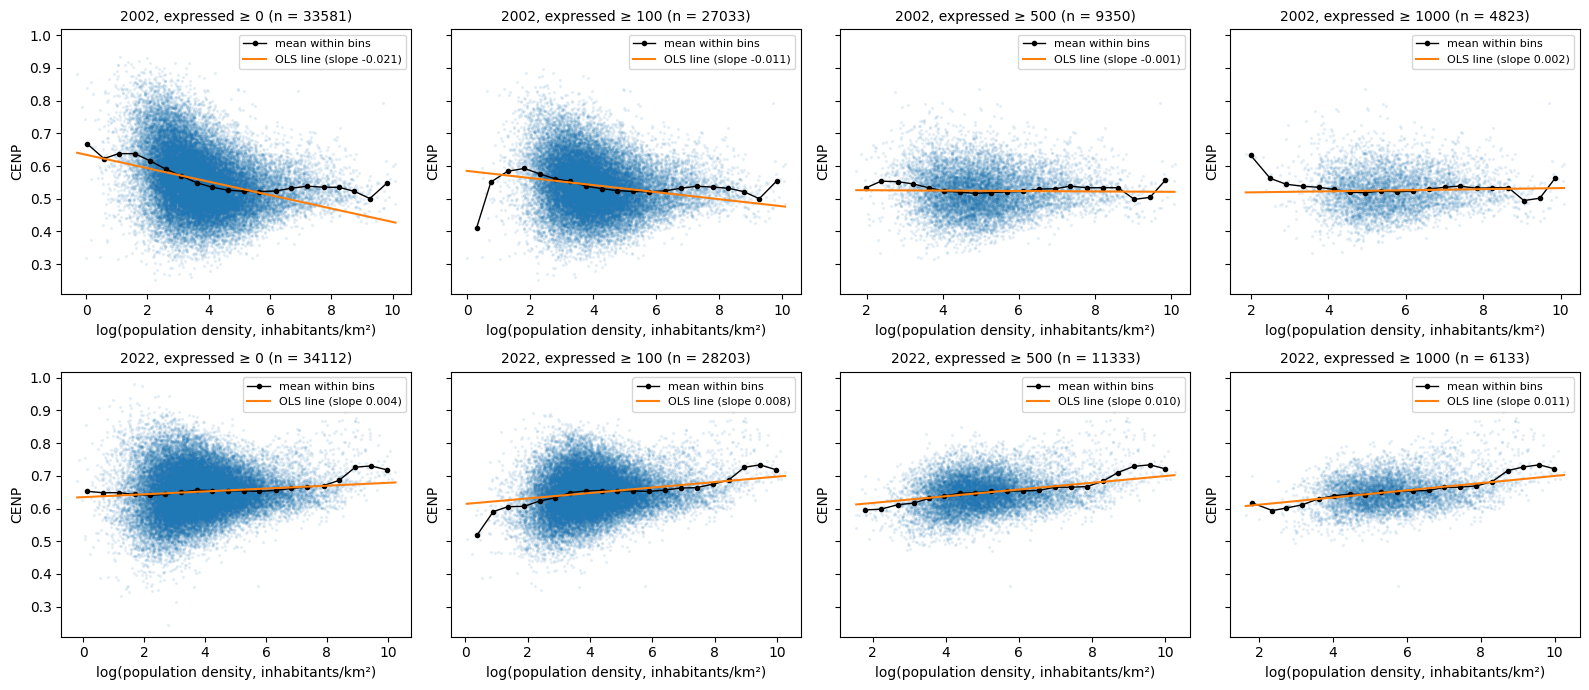

In [9]:
fig, axes = plt.subplots(len(YEARS), len(CUTOFFS), figsize=(16, 7), sharey=True)
for i, year in enumerate(YEARS):
    for j, cutoff in enumerate(CUTOFFS):
        sub = main[(main["year"] == year) & (main["expressed"] >= cutoff)]
        commune_scatter(sub, "CENP", axes[i, j], f"{year}, expressed ≥ {cutoff} (n = {len(sub)})", "CENP")
show_plot(fig)

## 4. Comparing the 2002 and 2022 relationships

CENP levels are not directly comparable across elections (16 vs 12 candidates); the slopes are. Pooled regression on
the main samples:

$$\text{CENP}_{it} = \beta_0 + \beta_1 \log\text{density}_{it} + \beta_2 \mathbb{1}[t=2022] + \beta_3 \log\text{density}_{it}\times\mathbb{1}[t=2022] + \varepsilon_{it}$$

$\beta_3$ = how much the density slope differs in 2022. Standard errors clustered by département.

In [10]:
pooled_data = main[["CENP", "log_density", "year", "department_code", "expressed"]].copy()
print(pooled_interaction(pooled_data).summary().tables[1])

TERM = "log_density:C(year)[T.2022]"
rows = []
for cutoff in CUTOFFS:
    d = pooled_data[pooled_data["expressed"] >= cutoff]
    fit = pooled_interaction(d)
    rows.append({"min_expressed": cutoff, "n": int(fit.nobs), "slope_2002": fit.params["log_density"],
                 "difference_2022": fit.params[TERM], "se_cluster": fit.bse[TERM], "p_cluster": fit.pvalues[TERM]})
pd.DataFrame(rows).set_index("min_expressed")

                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.6345      0.009     68.574      0.000       0.616       0.653
C(year)[T.2022]                 0.0003      0.011      0.027      0.979      -0.021       0.021
log_density                    -0.0206      0.002    -10.532      0.000      -0.024      -0.017
log_density:C(year)[T.2022]     0.0250      0.002     11.693      0.000       0.021       0.029


,n,slope_2002,difference_2022,se_cluster,p_cluster
min_expressed,,,,,
0,67693,-0.020573,0.024953,0.002134,1.380653e-31
100,55236,-0.010812,0.019170,0.002445,4.433921e-15
500,20683,-0.000620,0.010916,0.002174,5.131364e-07
1000,10956,0.001639,0.009347,0.002549,2.452025e-04


## 5. Secondary cliff measures

`cliff_magnitude` and `cliff_ratio`: same descriptive analysis as CENP (complements, not replacements).
`cliff_location` is discrete: distribution by year and across density deciles, no OLS.

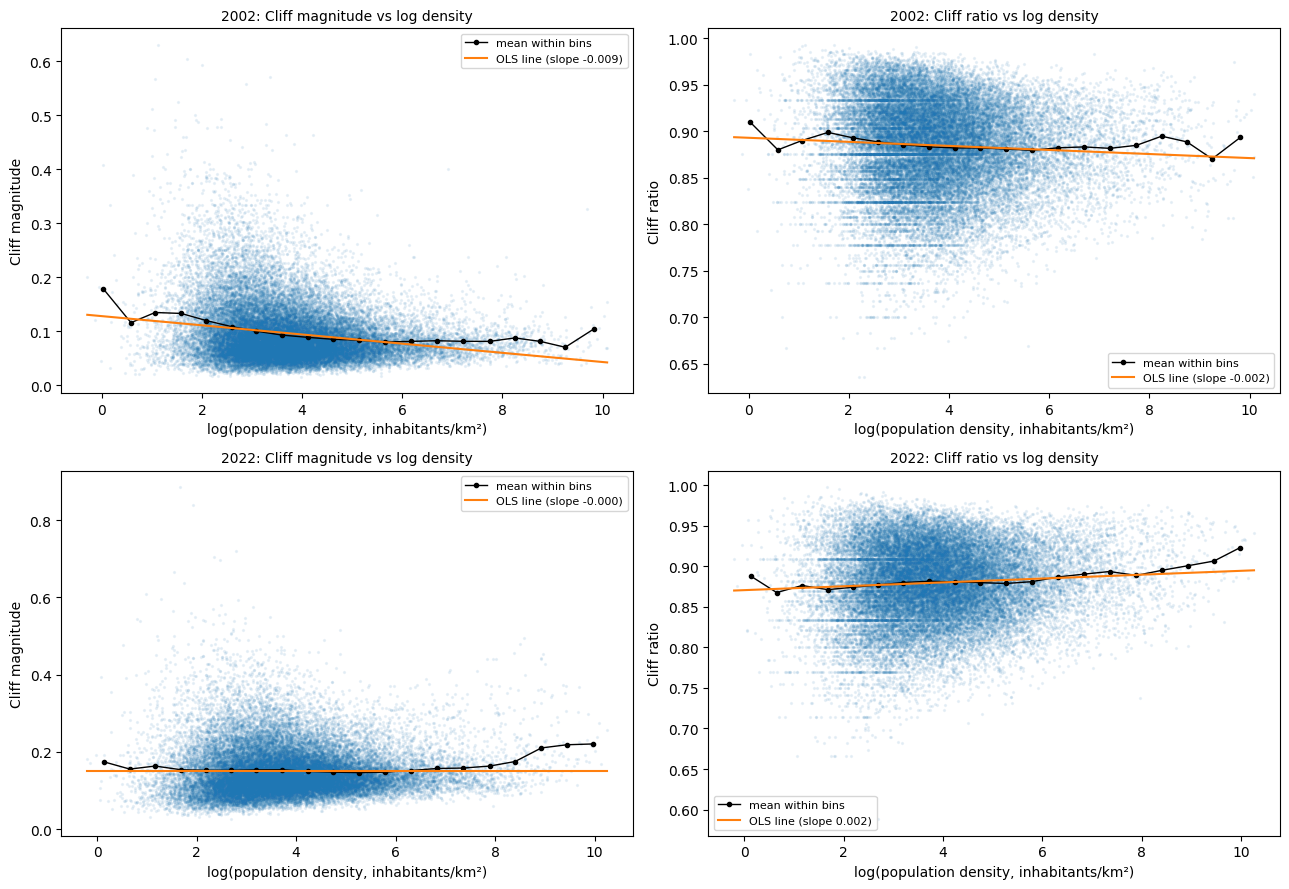

2002                                        2022                              
                      CENP cliff_magnitude   cliff_ratio          CENP cliff_magnitude   cliff_ratio
n             33581.000000    3.358100e+04  3.358100e+04  3.411200e+04    3.411200e+04  3.411200e+04
pearson_r        -0.287421   -2.045215e-01 -5.765684e-02  8.180033e-02   -4.694487e-06  6.821140e-02
pearson_p         0.000000   5.823275e-314  3.929824e-26  9.831408e-52    9.993082e-01  1.802088e-36
spearman_rho     -0.310497   -1.695818e-01 -8.580169e-02  7.698489e-02    4.481965e-02  3.879212e-02
spearman_p        0.000000   4.401589e-215  6.682782e-56  5.225800e-46    1.213336e-16  7.659204e-13
ols_coef         -0.020573   -8.501983e-03 -2.179113e-03  4.379877e-03   -2.248282e-07  2.385231e-03
ols_se            0.000374    2.220592e-04  2.059074e-04  2.889403e-04    2.593116e-04  1.888947e-04
ols_se_HC1        0.000381    2.323304e-04  1.982062e-04  2.932182e-04    2.902453e-04  1.919057e-04
ols_p             0.000000    0.000000e+00  3.929824e-26  9.831408e-52    9.993082e-01  1.802088e-36
ols_p_HC1         0.000000   1.597004e-287  4.551660e-28  2.720541e-50    9.993820e-01  2.165417e-35
ols_R2            0.082611    4.182904e-02  3.324311e-03  6.691294e-03    2.203671e-11  4.652796e-03

In [11]:
SECONDARY = {"cliff_magnitude": "Cliff magnitude", "cliff_ratio": "Cliff ratio"}
fig, axes = plt.subplots(len(YEARS), len(SECONDARY), figsize=(13, 9))
for i, year in enumerate(YEARS):
    sub = main[main["year"] == year]
    for j, (var, label) in enumerate(SECONDARY.items()):
        commune_scatter(sub.dropna(subset=[var]), var, axes[i, j], f"{year}: {label} vs log density", label)
show_plot(fig)

pd.concat({year: pd.DataFrame({var: association_stats(main[main["year"] == year].dropna(subset=[var]), var)
                               for var in ["CENP", *SECONDARY]})
           for year in YEARS}, axis=1)

In [12]:
print("cliff_location — distribution by year (share of communes):")
display(pd.crosstab(main["cliff_location"], main["year"], normalize="columns").round(3))
for year in YEARS:
    sub = main[main["year"] == year]
    print(f"\n{year}: cliff_location by density decile (row shares)")
    display(pd.crosstab(sub["density_decile"], sub["cliff_location"], normalize="index").round(2))

cliff_location — distribution by year (share of communes):


year,2002,2022
cliff_location,,
1.0,0.448,0.413
2.0,0.276,0.307
3.0,0.195,0.249
4.0,0.056,0.025
5.0,0.015,0.004
6.0,0.005,0.001
7.0,0.002,0.000
8.0,0.001,0.000
9.0,0.001,0.000



2002: cliff_location by density decile (row shares)


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
density_decile,,,,,,,,,,,,,,,
1,0.55,0.24,0.13,0.05,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.50,0.27,0.13,0.07,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.49,0.29,0.13,0.06,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.46,0.29,0.15,0.07,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.47,0.29,0.16,0.06,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.45,0.30,0.16,0.06,0.02,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.43,0.30,0.19,0.06,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.41,0.28,0.23,0.05,0.01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.41,0.26,0.28,0.04,0.01,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



2022: cliff_location by density decile (row shares)


cliff_location,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,10.0
density_decile,,,,,,,,,
1,0.47,0.30,0.16,0.05,0.01,0.01,0.0,0.0,0.0
2,0.44,0.32,0.19,0.04,0.01,0.00,0.0,0.0,0.0
3,0.42,0.31,0.23,0.04,0.01,0.00,0.0,0.0,0.0
4,0.42,0.33,0.22,0.03,0.00,0.00,0.0,0.0,0.0
5,0.41,0.32,0.23,0.03,0.00,0.00,0.0,0.0,0.0
6,0.38,0.34,0.26,0.02,0.00,0.00,0.0,0.0,0.0
7,0.37,0.34,0.27,0.02,0.00,0.00,0.0,0.0,0.0
8,0.40,0.33,0.27,0.01,0.00,0.00,0.0,0.0,0.0
9,0.40,0.30,0.29,0.01,0.00,0.00,0.0,0.0,0.0
